In [9]:
# ============================================
# GREENLAMBDA ML TRAINING - LOCAL MACHINE
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)




In [10]:
# Load dataset
print("\n" + "="*60)
print("LOADING DATA")
print("="*60)

df = pd.read_csv('final_ml_dataset_clean.csv')

print(f"✓ Dataset loaded: {len(df)} rows, {len(df.columns)} columns")
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

# Check for missing values
missing = df.isnull().sum()
if missing.sum() == 0:
    print(f"\n✓ No missing values")
else:
    print(f"\n⚠ Missing values found:")
    print(missing[missing > 0])

# Display first few rows
print("\nFirst 5 rows:")
df.head()


LOADING DATA
✓ Dataset loaded: 1332 rows, 23 columns

Dataset shape: (1332, 23)

Column names:
['function_name', 'function_type', 'input_size', 'memory_config_mb', 'cold_start', 'lines_of_code', 'num_loops', 'num_conditionals', 'num_function_calls', 'cyclomatic_complexity', 'max_nesting_depth', 'local_duration_ms', 'local_cpu_percent', 'local_memory_mb', 'local_energy_wh', 'aws_duration_ms', 'aws_memory_used_mb', 'aws_cold_start', 'aws_energy_estimate_wh', 'duration_ratio', 'memory_efficiency', 'energy_target_wh', 'calibration_ratio']

✓ No missing values

First 5 rows:


,function_name,function_type,input_size,memory_config_mb,cold_start,lines_of_code,num_loops,num_conditionals,num_function_calls,cyclomatic_complexity,max_nesting_depth,local_duration_ms,local_cpu_percent,local_memory_mb,local_energy_wh,aws_duration_ms,aws_memory_used_mb,aws_cold_start,aws_energy_estimate_wh,duration_ratio,memory_efficiency,energy_target_wh,calibration_ratio
0,bubble-sort,cpu,Small,256,True,12,2,1,7,4,3,82.764,17.44,123.63,0.055719,570.48,35,True,0.000128,6.892852,0.136719,0.055719,0.002304
1,bubble-sort,cpu,Small,256,False,12,2,1,7,4,3,82.764,17.44,123.63,0.055719,560.38,35,False,0.000126,6.770818,0.136719,0.055719,0.002263
2,bubble-sort,cpu,Small,256,False,12,2,1,7,4,3,82.764,17.44,123.63,0.055719,568.68,35,False,0.000128,6.871103,0.136719,0.055719,0.002296
3,bubble-sort,cpu,Small,256,False,12,2,1,7,4,3,82.764,17.44,123.63,0.055719,555.88,35,False,0.000125,6.716447,0.136719,0.055719,0.002245
4,bubble-sort,cpu,Small,256,False,12,2,1,7,4,3,82.764,17.44,123.63,0.055719,565.56,35,False,0.000127,6.833406,0.136719,0.055719,0.002284


In [11]:
# Summary statistics
print("\n" + "="*60)
print("DATA SUMMARY")
print("="*60)

print("\nTarget Variable (energy_target_wh) Statistics:")
print(f"  Mean:   {df['energy_target_wh'].mean():.4f} Wh")
print(f"  Median: {df['energy_target_wh'].median():.4f} Wh")
print(f"  Std:    {df['energy_target_wh'].std():.4f} Wh")
print(f"  Min:    {df['energy_target_wh'].min():.4f} Wh")
print(f"  Max:    {df['energy_target_wh'].max():.4f} Wh")

print("\nFunction Type Distribution:")
print(df['function_type'].value_counts())

print("\nMemory Configuration Distribution:")
print(df['memory_config_mb'].value_counts())

print("\nCold Start Distribution:")
print(df['cold_start'].value_counts())
print(f"Cold start percentage: {df['cold_start'].sum() / len(df) * 100:.1f}%")


DATA SUMMARY

Target Variable (energy_target_wh) Statistics:
  Mean:   2.9733 Wh
  Median: 3.0251 Wh
  Std:    1.3919 Wh
  Min:    0.0557 Wh
  Max:    5.1588 Wh

Function Type Distribution:
function_type
io        450
cpu       444
memory    438
Name: count, dtype: int64

Memory Configuration Distribution:
memory_config_mb
256     447
1024    443
512     442
Name: count, dtype: int64

Cold Start Distribution:
cold_start
False    1287
True       45
Name: count, dtype: int64
Cold start percentage: 3.4%



DATA VISUALIZATION
✓ Saved: energy_distributions.png


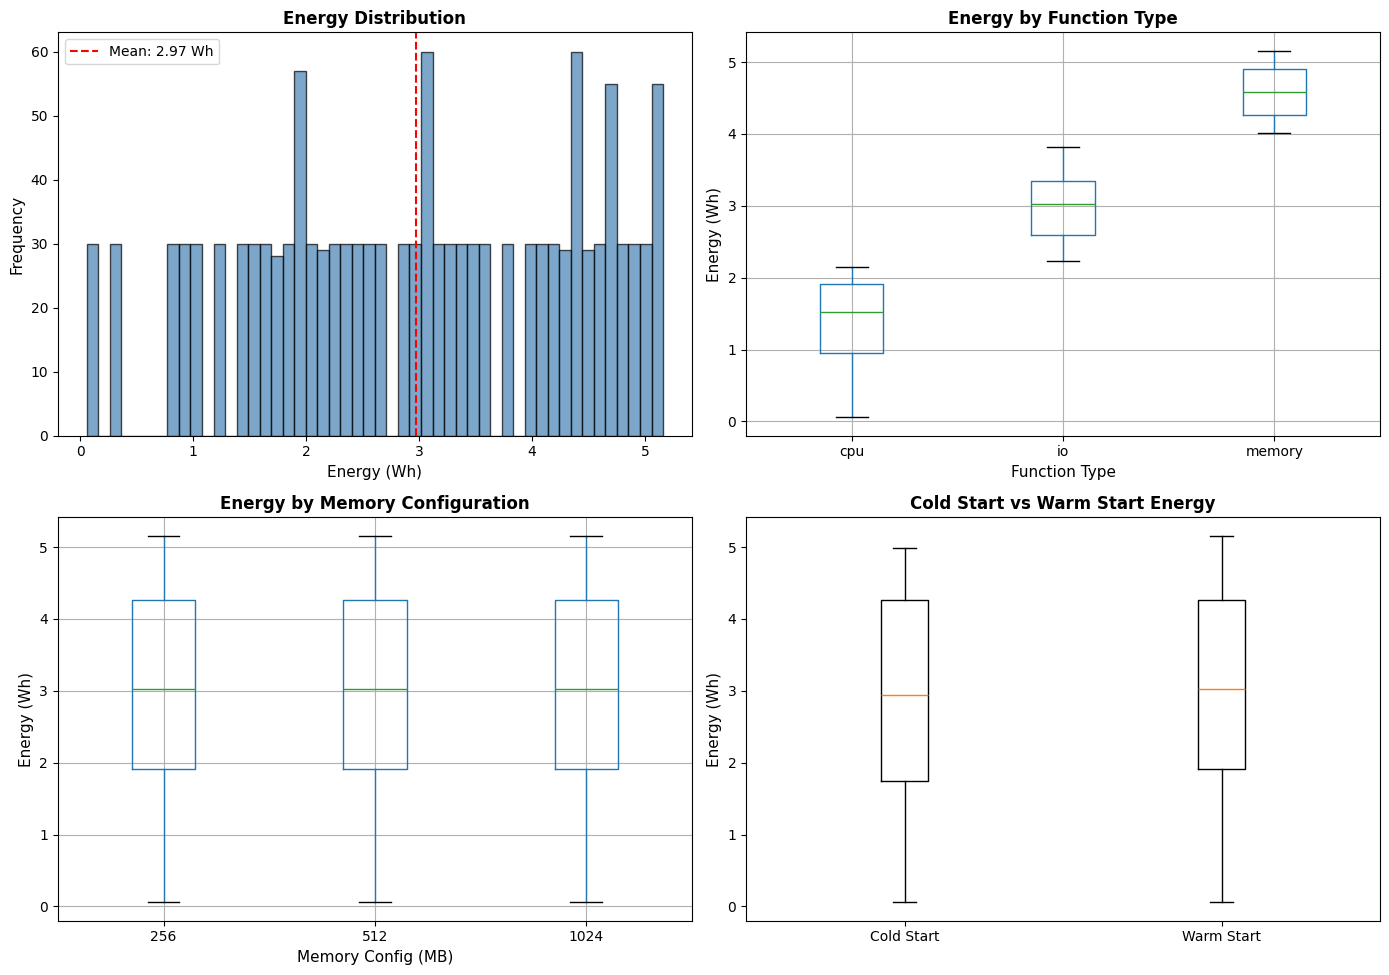

In [12]:
# Create visualizations
print("\n" + "="*60)
print("DATA VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Energy distribution histogram
axes[0, 0].hist(df['energy_target_wh'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Energy (Wh)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].set_title('Energy Distribution', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df['energy_target_wh'].mean(), color='red', linestyle='--', 
                    label=f'Mean: {df["energy_target_wh"].mean():.2f} Wh')
axes[0, 0].legend()

# 2. Energy by Function Type
df.boxplot(column='energy_target_wh', by='function_type', ax=axes[0, 1])
axes[0, 1].set_xlabel('Function Type', fontsize=11)
axes[0, 1].set_ylabel('Energy (Wh)', fontsize=11)
axes[0, 1].set_title('Energy by Function Type', fontsize=12, fontweight='bold')
axes[0, 1].get_figure().suptitle('')

# 3. Energy by Memory Configuration
df.boxplot(column='energy_target_wh', by='memory_config_mb', ax=axes[1, 0])
axes[1, 0].set_xlabel('Memory Config (MB)', fontsize=11)
axes[1, 0].set_ylabel('Energy (Wh)', fontsize=11)
axes[1, 0].set_title('Energy by Memory Configuration', fontsize=12, fontweight='bold')
axes[1, 0].get_figure().suptitle('')

# 4. Cold vs Warm Start
cold_warm_energy = [
    df[df['cold_start']==True]['energy_target_wh'],
    df[df['cold_start']==False]['energy_target_wh']
]
axes[1, 1].boxplot(cold_warm_energy, labels=['Cold Start', 'Warm Start'])
axes[1, 1].set_ylabel('Energy (Wh)', fontsize=11)
axes[1, 1].set_title('Cold Start vs Warm Start Energy', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('energy_distributions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: energy_distributions.png")
plt.show()


FEATURE CORRELATION ANALYSIS

Top 10 Features Correlated with Energy:
local_energy_wh       1.000000
local_memory_mb       0.870903
aws_memory_used_mb    0.300370
memory_efficiency     0.155629
lines_of_code         0.135824
local_cpu_percent     0.042251
duration_ratio        0.017033
memory_config_mb     -0.005413
num_loops            -0.022719
num_function_calls   -0.100130
Name: energy_target_wh, dtype: float64

Bottom 10 Features (Least Correlated):
memory_config_mb         -0.005413
num_loops                -0.022719
num_function_calls       -0.100130
cyclomatic_complexity    -0.152583
aws_duration_ms          -0.347343
local_duration_ms        -0.361590
aws_energy_estimate_wh   -0.402380
num_conditionals         -0.429713
calibration_ratio        -0.548146
max_nesting_depth        -0.584009
Name: energy_target_wh, dtype: float64

✓ Saved: correlation_heatmap.png


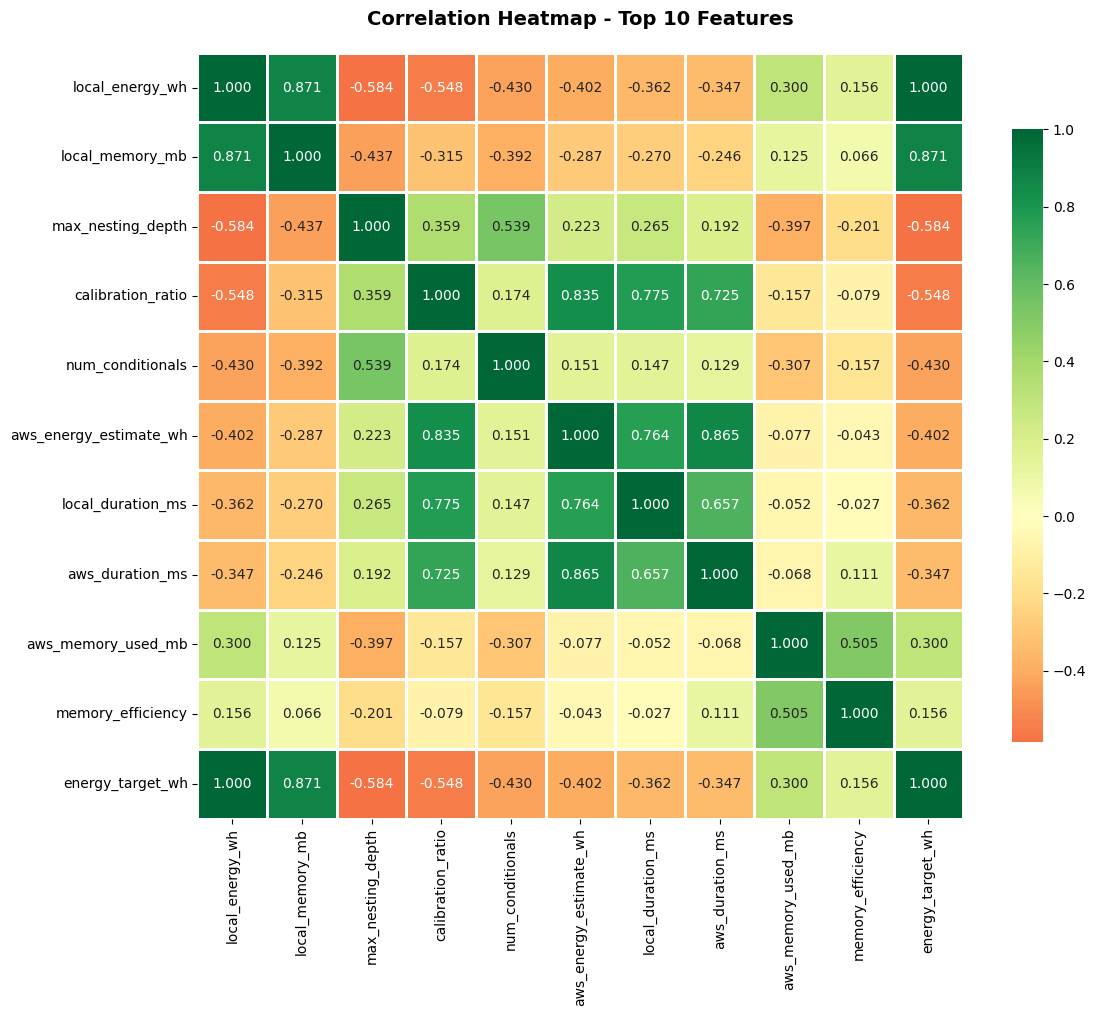

In [13]:
# Correlation analysis
print("\n" + "="*60)
print("FEATURE CORRELATION ANALYSIS")
print("="*60)

# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation with target
correlations = df[numeric_cols].corr()['energy_target_wh'].drop('energy_target_wh')
correlations = correlations.sort_values(ascending=False)

print("\nTop 10 Features Correlated with Energy:")
print(correlations.head(10))

print("\nBottom 10 Features (Least Correlated):")
print(correlations.tail(10))

# Correlation heatmap (top features)
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
corr_matrix = df[top_features + ['energy_target_wh']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - Top 10 Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: correlation_heatmap.png")
plt.show()

In [14]:
# Define features and target
print("\n" + "="*60)
print("PREPARING DATA FOR MACHINE LEARNING")
print("="*60)

# Feature columns (inputs for the model)
feature_columns = [
    # AWS Configuration
    'memory_config_mb',      
    'cold_start',            
    
    # Code Features (static analysis)
    'lines_of_code',         
    'num_loops',             
    'num_conditionals',      
    'num_function_calls',    
    'cyclomatic_complexity', 
    'max_nesting_depth',     
    
    # Local Execution Metrics (ground truth)
    'local_duration_ms',     
    'local_cpu_percent',     
    'local_memory_mb',       
    
    # AWS Execution Metrics
    'aws_duration_ms',       
    'aws_memory_used_mb',    
    
    # Derived Features
    'duration_ratio',        
    'memory_efficiency',     
    'calibration_ratio'      
]

# Separate features (X) and target (y)
X = df[feature_columns].copy()
y = df['energy_target_wh'].copy()

print(f"✓ Features (X) shape: {X.shape}")
print(f"✓ Target (y) shape: {y.shape}")
print(f"\nTotal features: {len(feature_columns)}")
print("\nFeature list:")
for i, feat in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {feat}")


PREPARING DATA FOR MACHINE LEARNING
✓ Features (X) shape: (1332, 16)
✓ Target (y) shape: (1332,)

Total features: 16

Feature list:
   1. memory_config_mb
   2. cold_start
   3. lines_of_code
   4. num_loops
   5. num_conditionals
   6. num_function_calls
   7. cyclomatic_complexity
   8. max_nesting_depth
   9. local_duration_ms
  10. local_cpu_percent
  11. local_memory_mb
  12. aws_duration_ms
  13. aws_memory_used_mb
  14. duration_ratio
  15. memory_efficiency
  16. calibration_ratio


In [15]:
# Split data into training and testing sets
print("\n" + "="*60)
print("SPLITTING DATA")
print("="*60)

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,           # 20% for testing
    random_state=42,         # For reproducibility
    stratify=df['function_type']  # Ensure balanced split
)

print(f"✓ Training set: {len(X_train)} rows ({len(X_train)/len(X)*100:.1f}%)")
print(f"✓ Testing set:  {len(X_test)} rows ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification
print("\nFunction type distribution in training set:")
train_indices = X_train.index
print(df.loc[train_indices, 'function_type'].value_counts())

print("\nFunction type distribution in testing set:")
test_indices = X_test.index
print(df.loc[test_indices, 'function_type'].value_counts())


SPLITTING DATA
✓ Training set: 1065 rows (80.0%)
✓ Testing set:  267 rows (20.0%)

Function type distribution in training set:
function_type
io        360
cpu       355
memory    350
Name: count, dtype: int64

Function type distribution in testing set:
function_type
io        90
cpu       89
memory    88
Name: count, dtype: int64


In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"  Training data scaled: {X_train_scaled.shape}")
print(f"  Testing data scaled:  {X_test_scaled.shape}")
print(f"  Original mean: {X_train[feature_columns[0]].mean():.2f}")
print(f"  Original std:  {X_train[feature_columns[0]].std():.2f}")
print(f"  Scaled mean:   {X_train_scaled[:, 0].mean():.2f}")
print(f"  Scaled std:    {X_train_scaled[:, 0].std():.2f}")

  Training data scaled: (1065, 16)
  Testing data scaled:  (267, 16)
  Original mean: 588.68
  Original std:  318.16
  Scaled mean:   -0.00
  Scaled std:    1.00


In [21]:
start_time = time.time()
model_lr = LinearRegression()
model_lr.fit(X_train_scaled,X_test)

ValueError: Found input variables with inconsistent numbers of samples: [1065, 267]